# Exploratory Data Analysis
Predicting Irrigation Need — Season 6, Episode 4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


In [2]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')
print(train.shape, test.shape)
train.head()

(630000, 21) (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [5]:
train.set_index('id', inplace=True)

In [6]:
numeric_cols = train.select_dtypes(include='number').columns
print(numeric_cols)

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object')


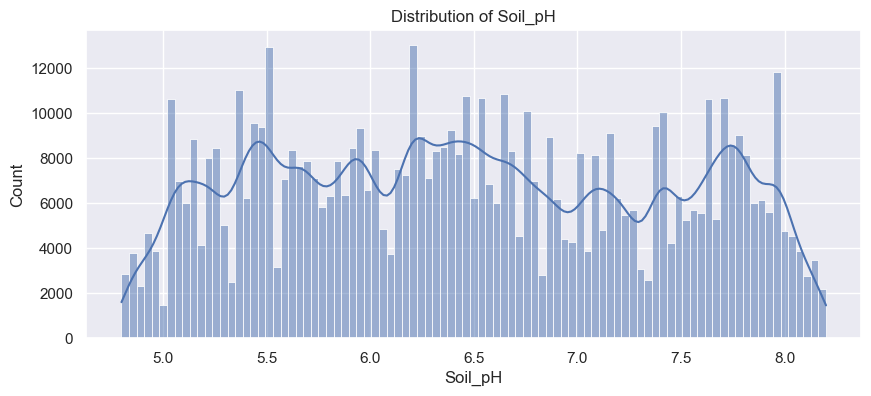

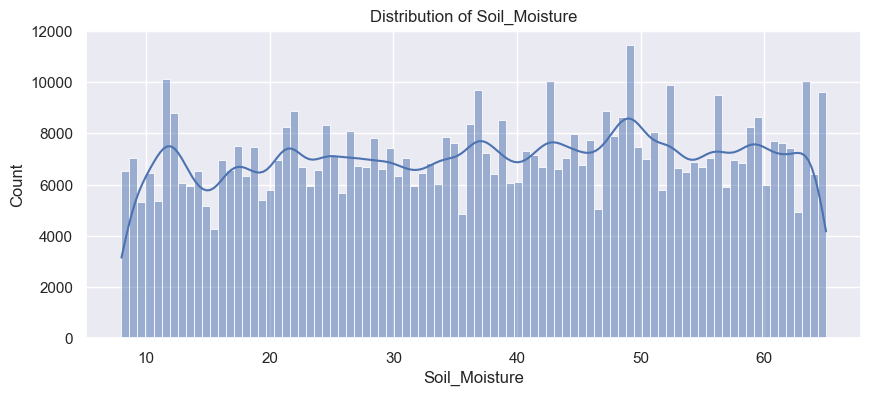

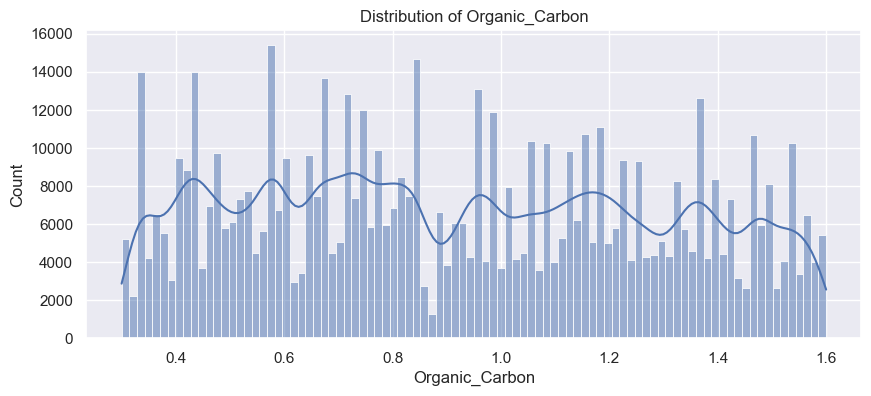

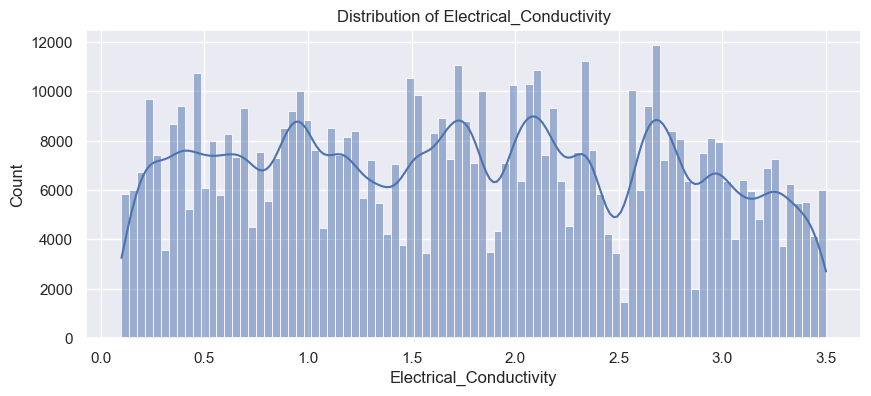

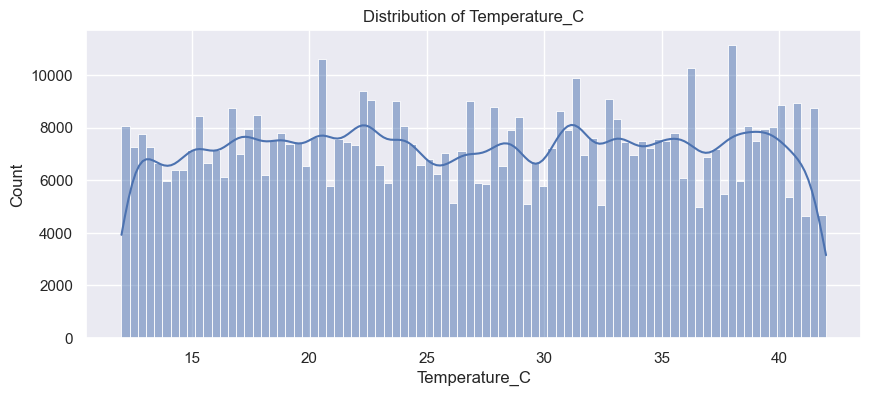

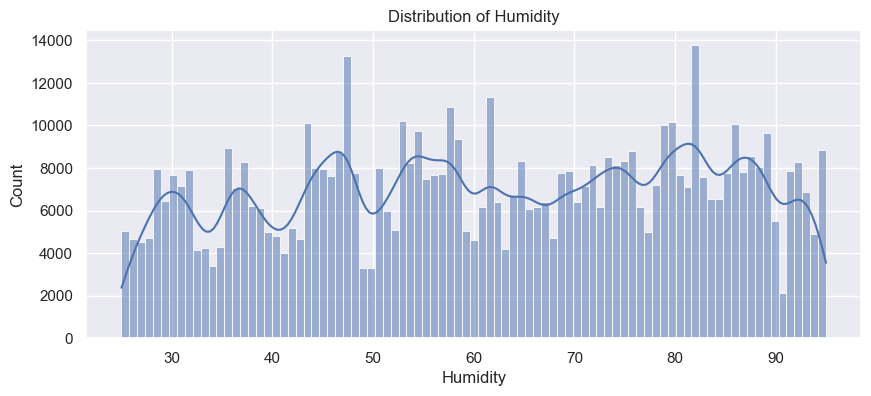

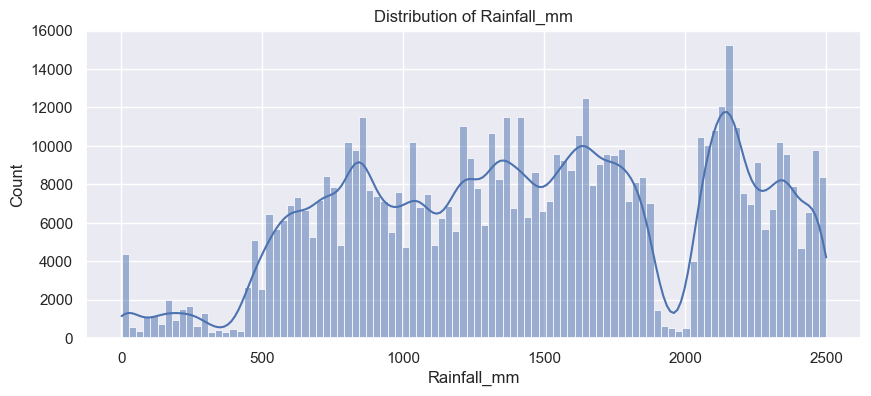

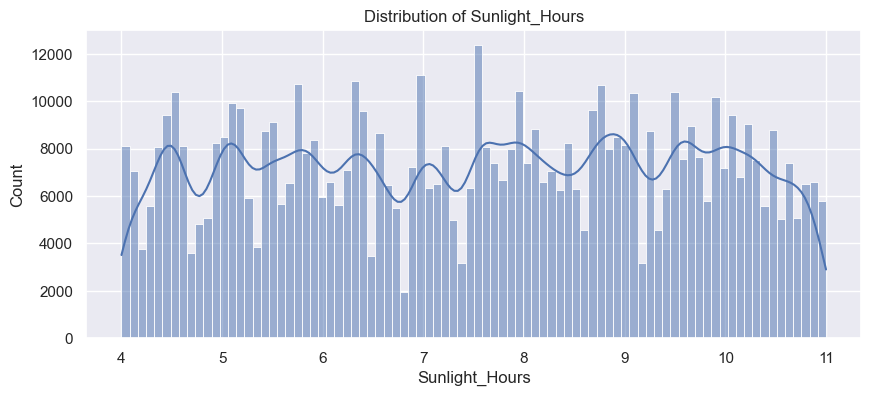

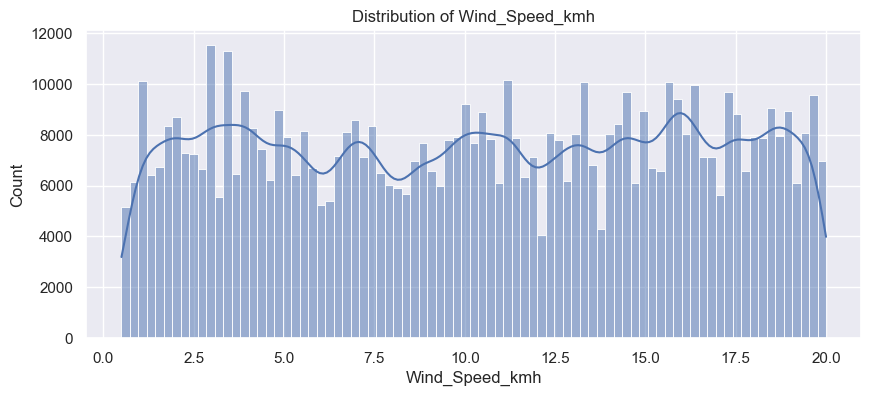

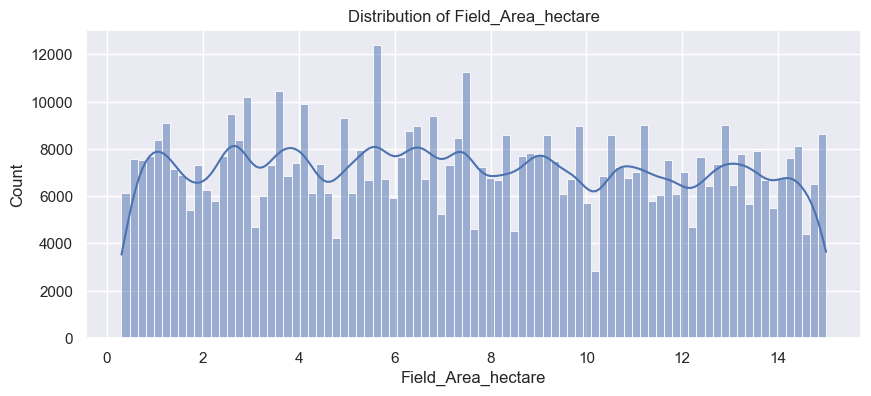

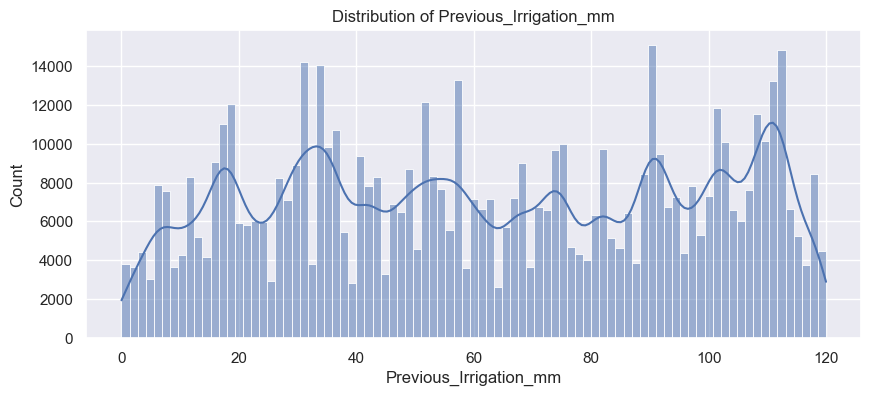

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(train[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [8]:
categorical_cols = train.select_dtypes(include='object').columns

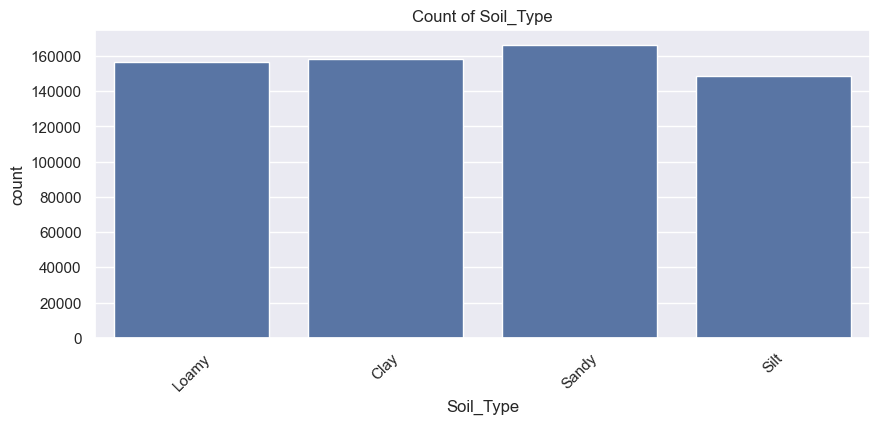

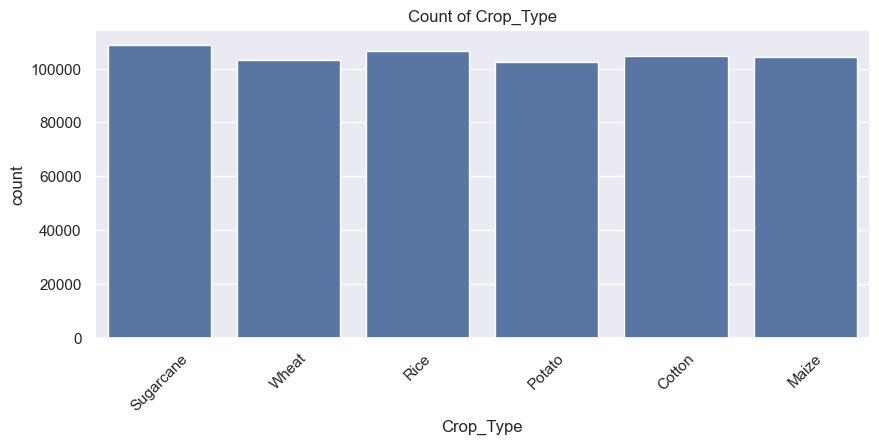

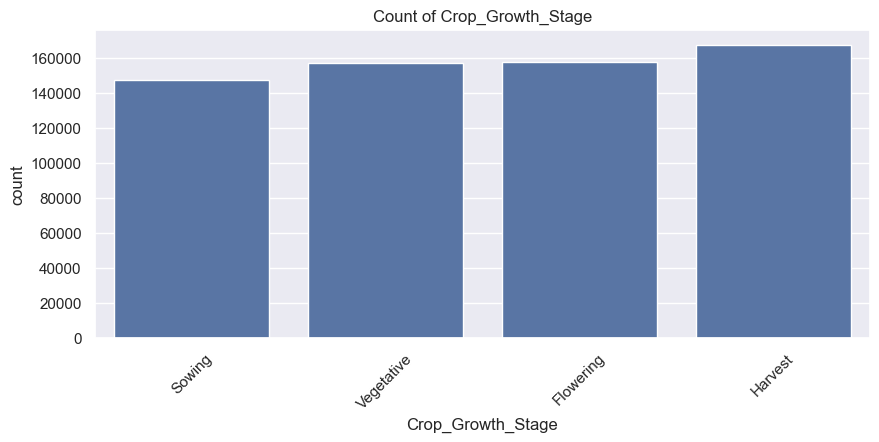

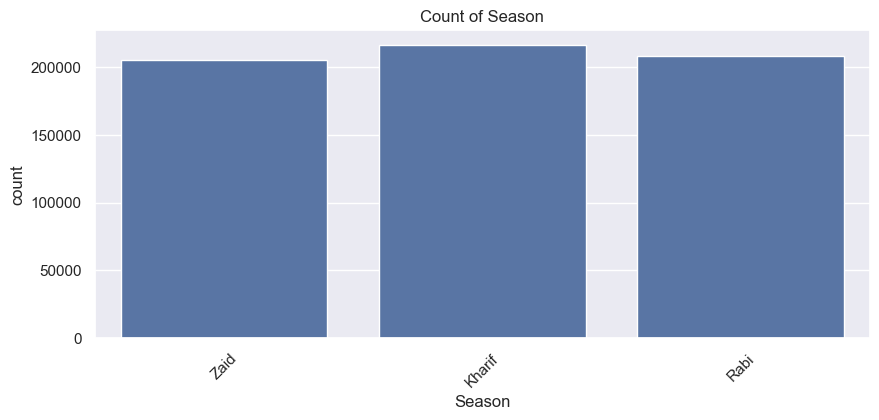

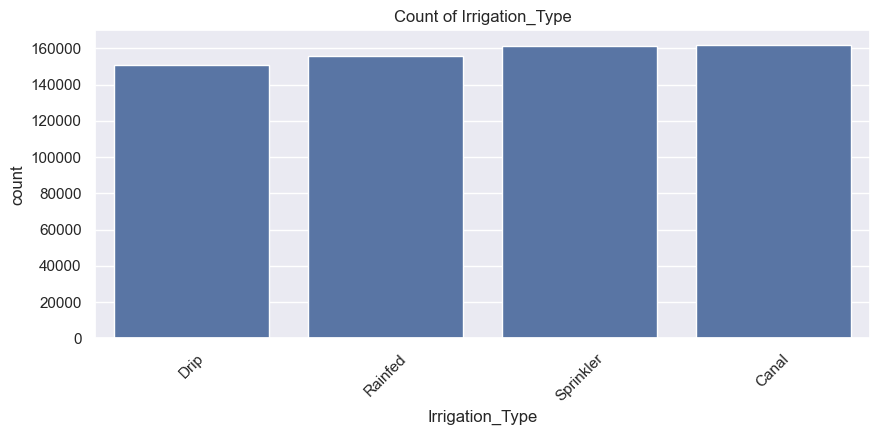

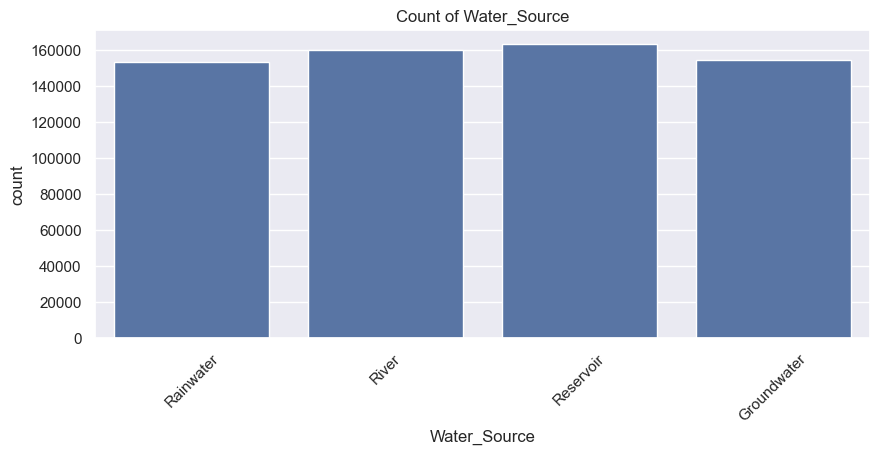

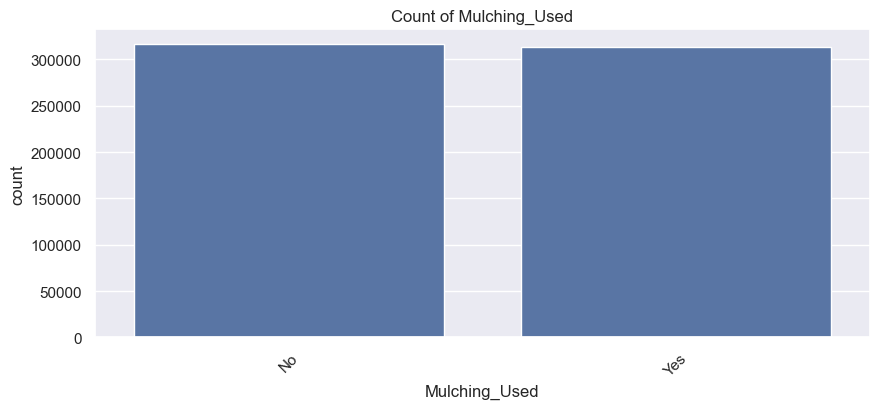

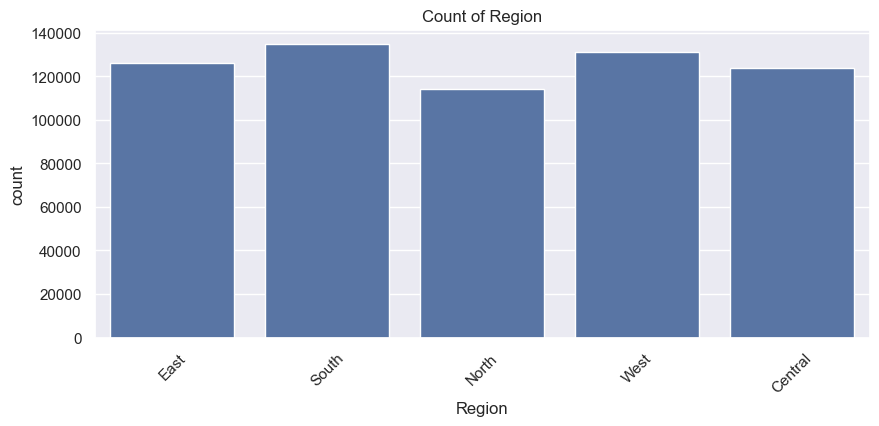

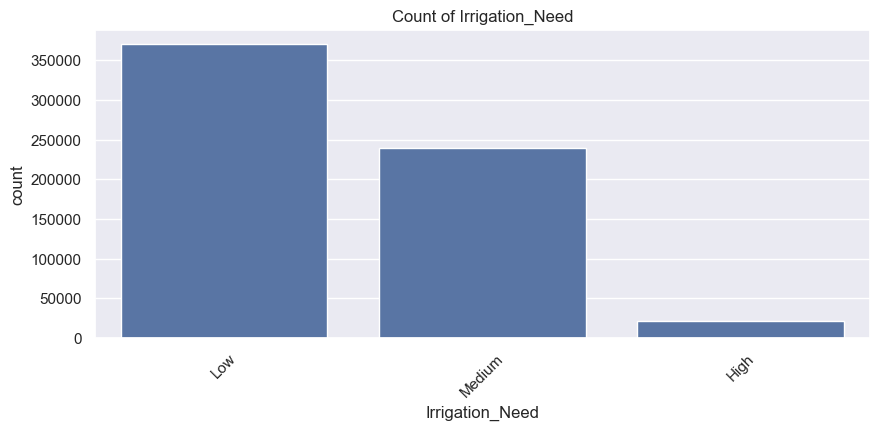

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=train)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

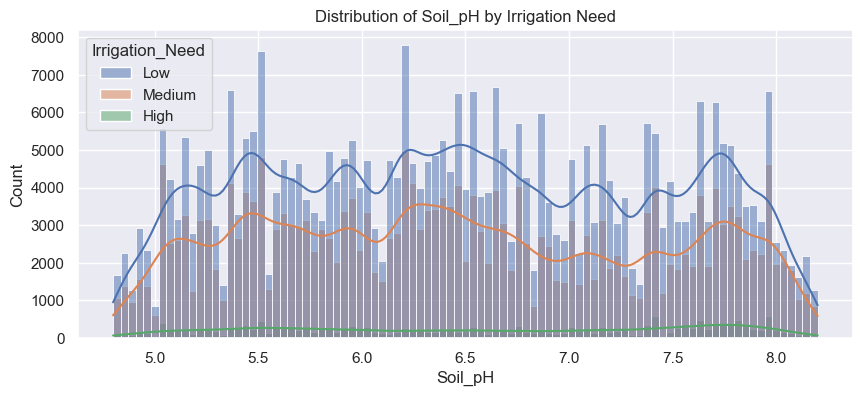

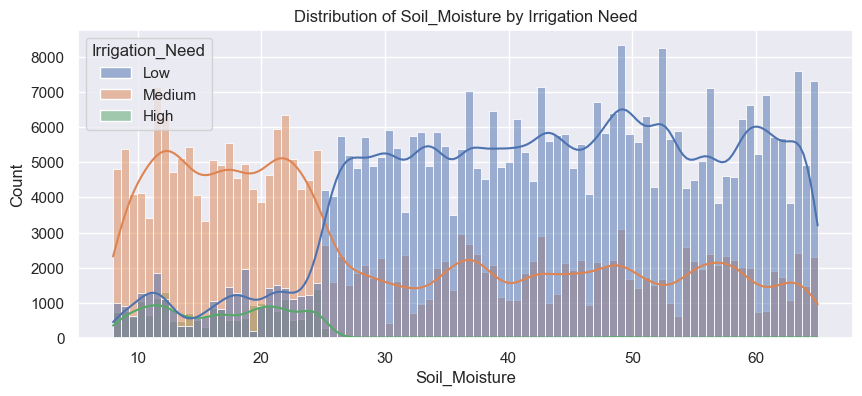

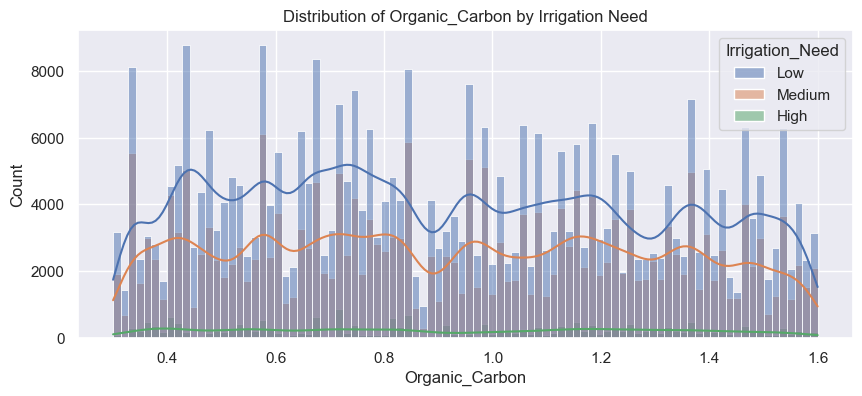

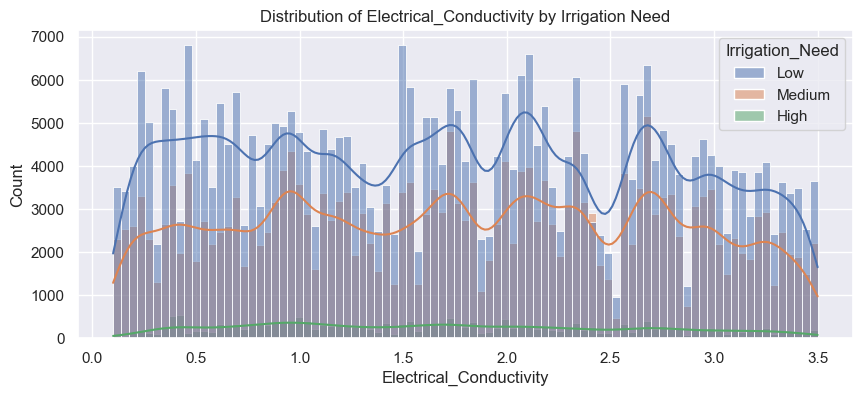

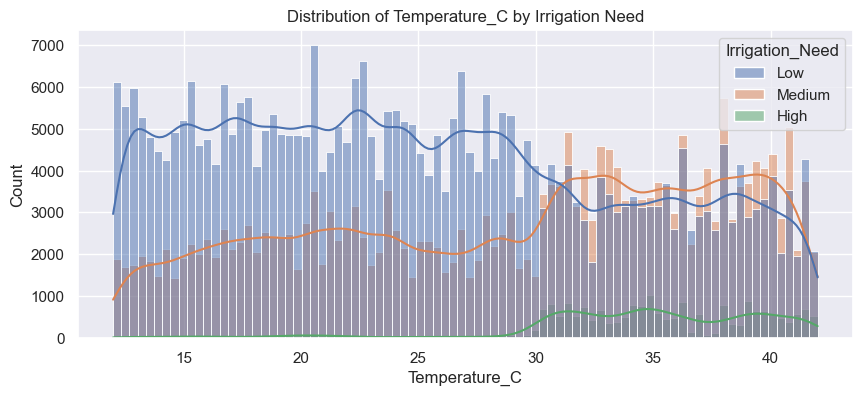

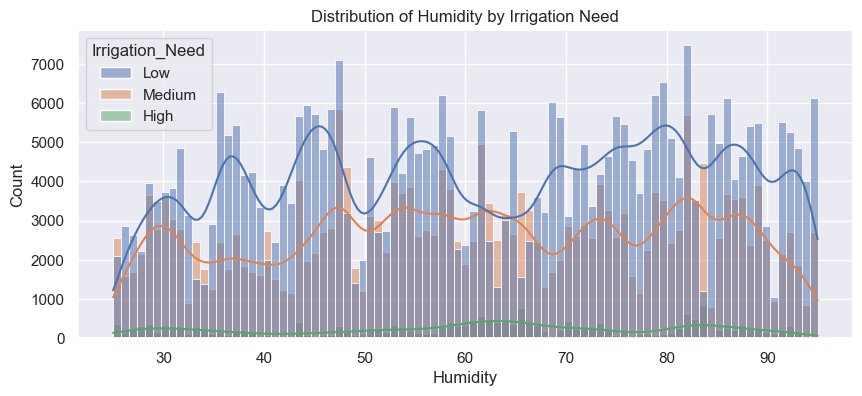

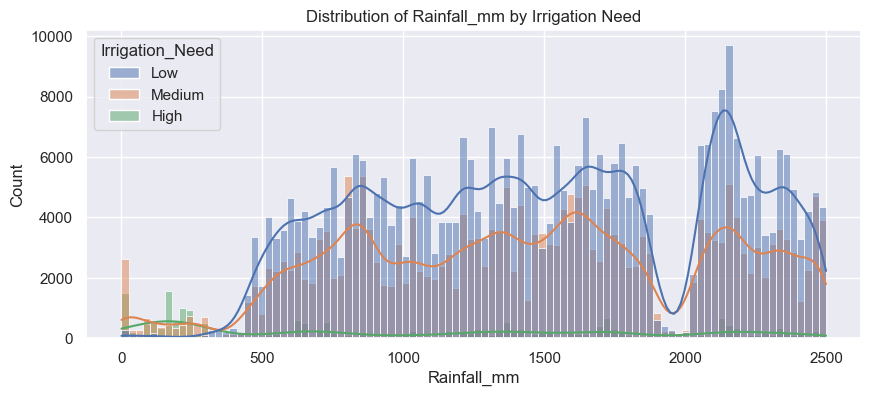

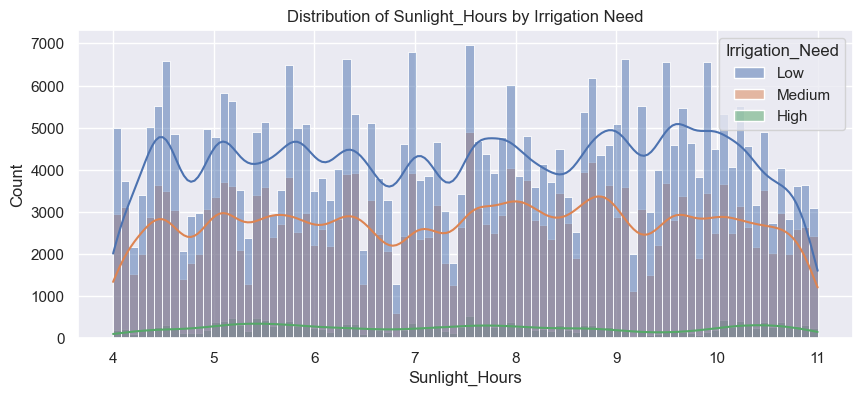

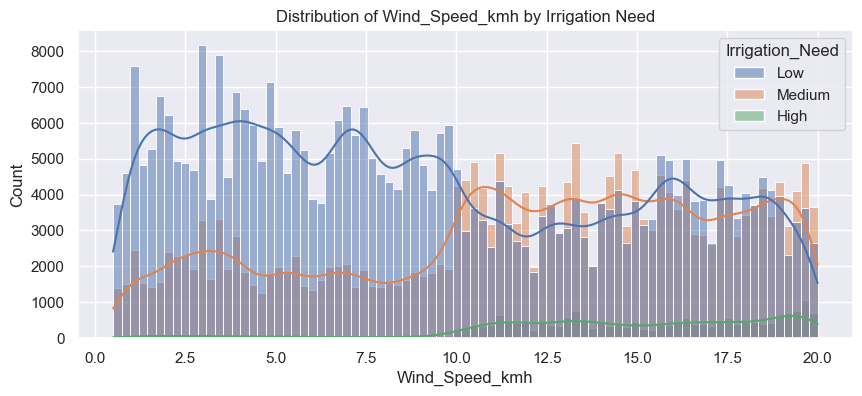

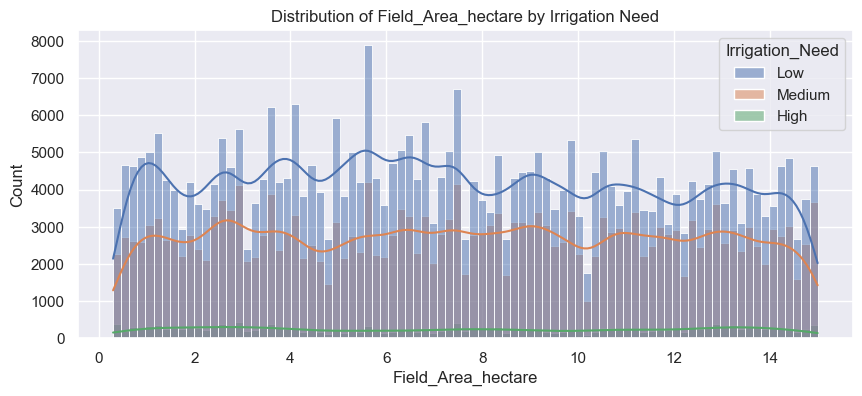

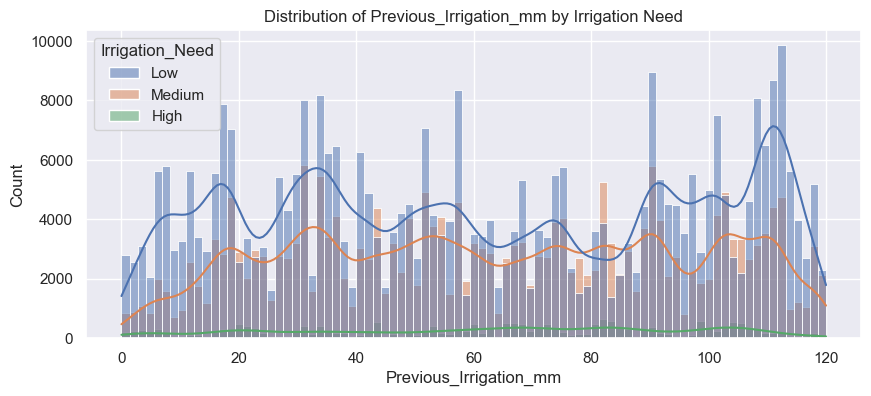

In [10]:
# Plotting distribution of numeric features according to irrigation_need
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=train, x=col, hue='Irrigation_Need', kde=True)
    plt.title(f'Distribution of {col} by Irrigation Need')
    plt.show()

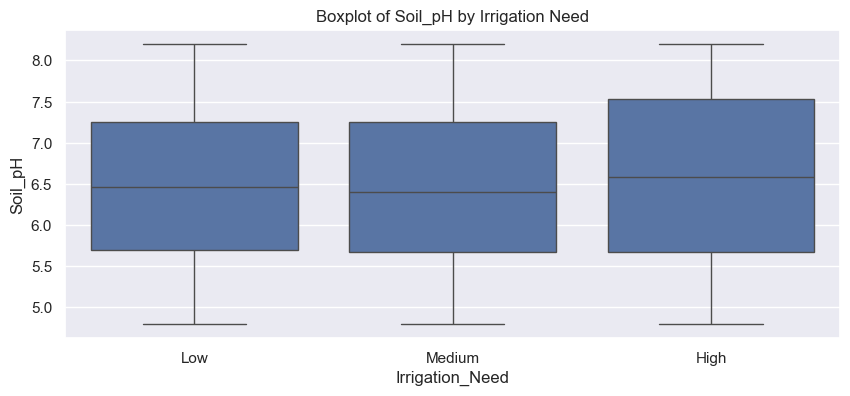

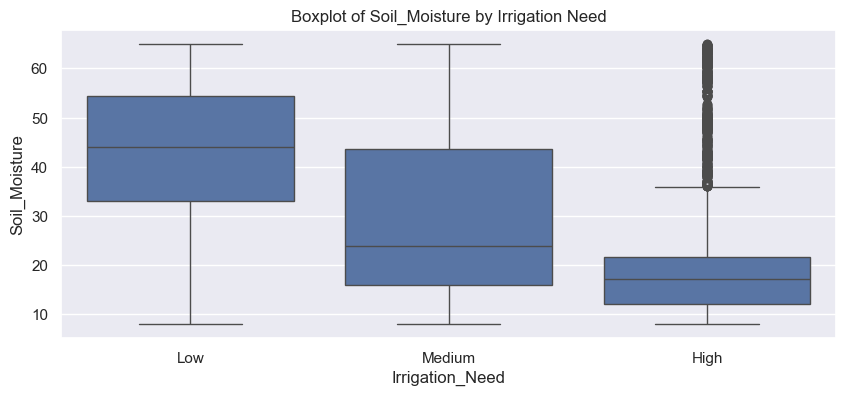

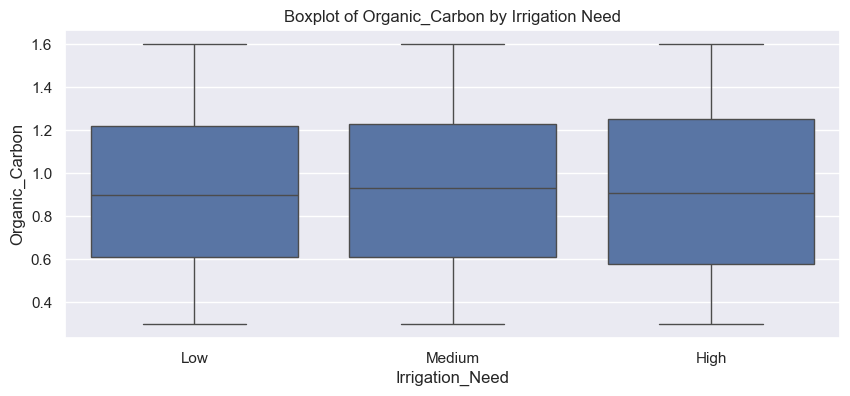

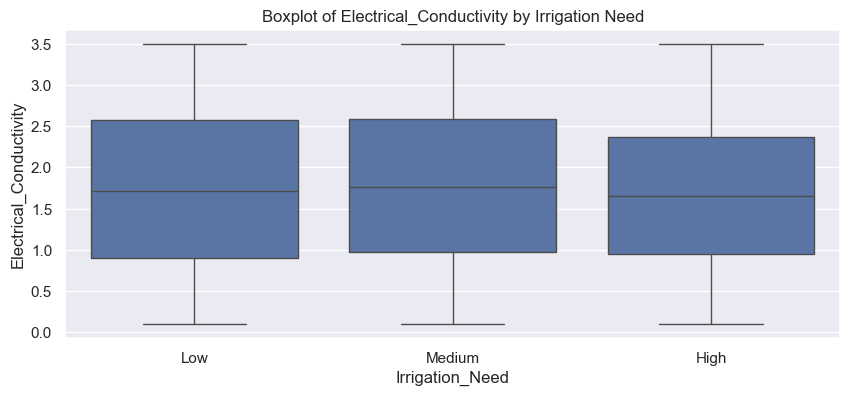

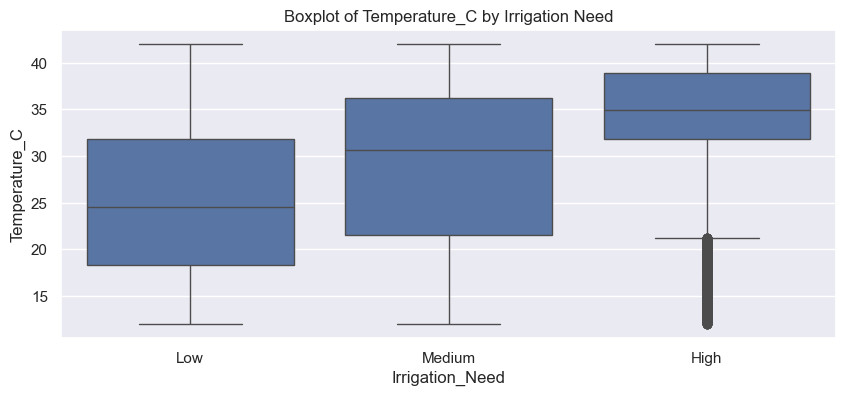

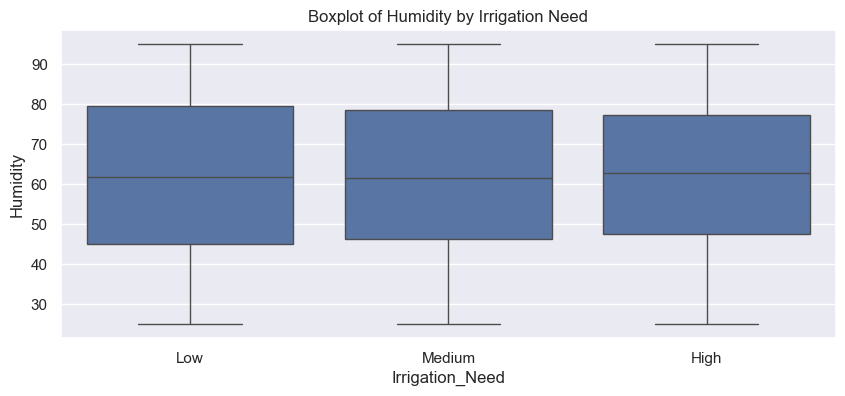

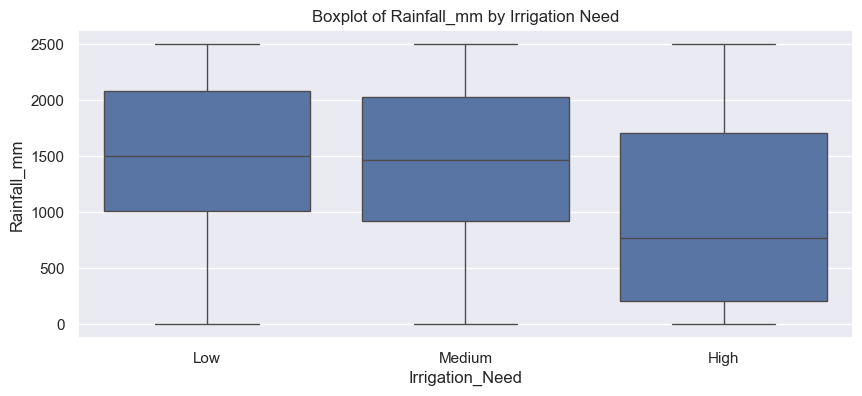

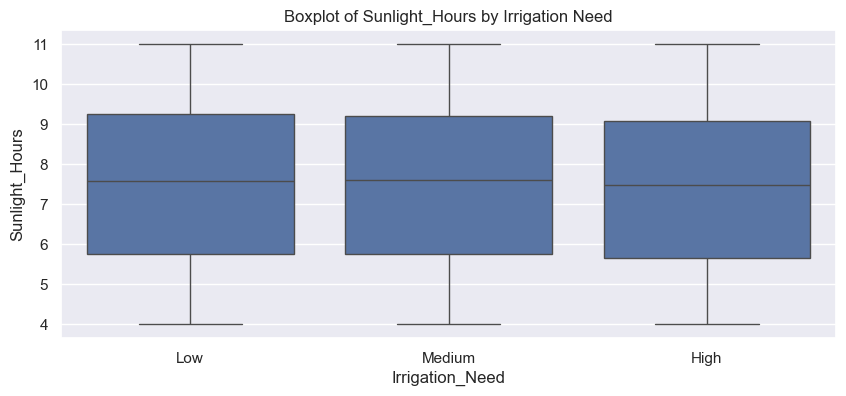

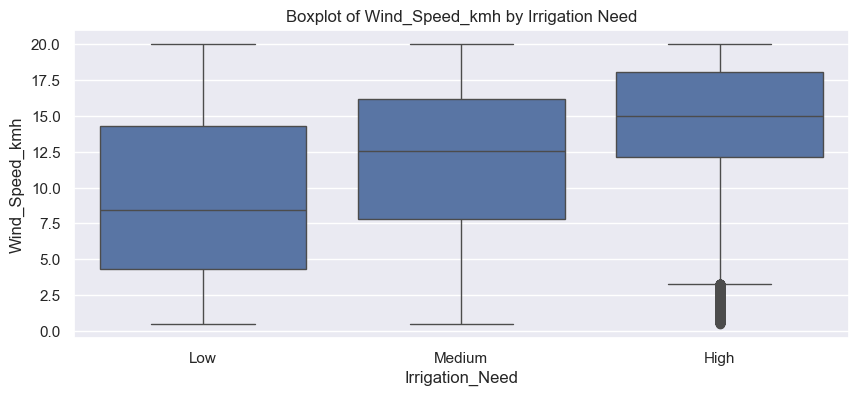

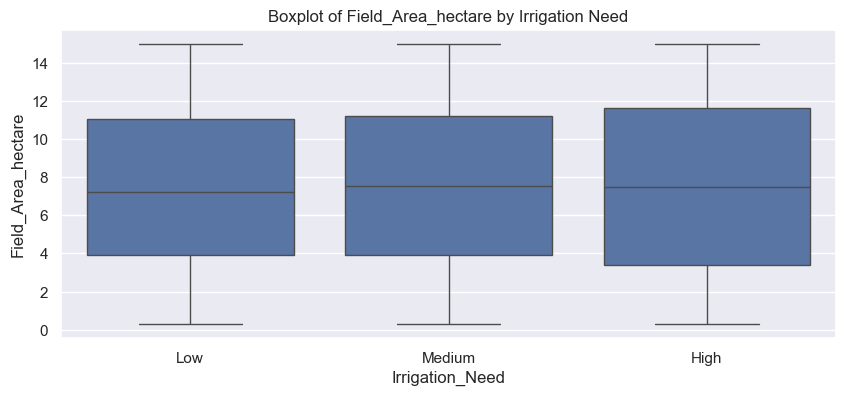

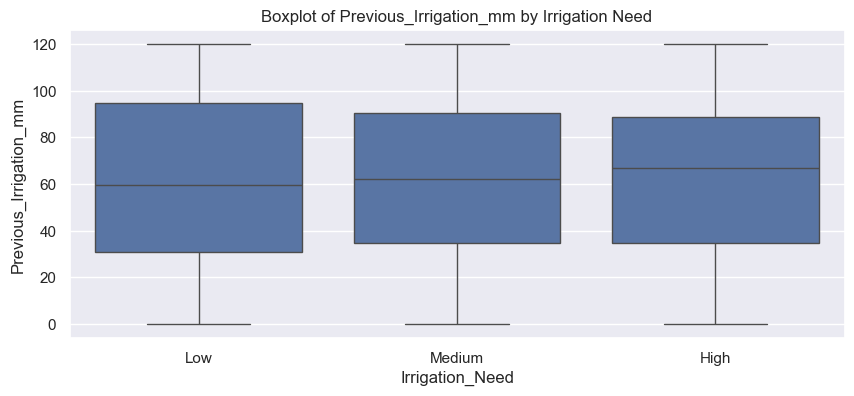

In [11]:
# Plot boxplots for numeric features by irrigation_need
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Irrigation_Need', y=col, data=train)
    plt.title(f'Boxplot of {col} by Irrigation Need')
    plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

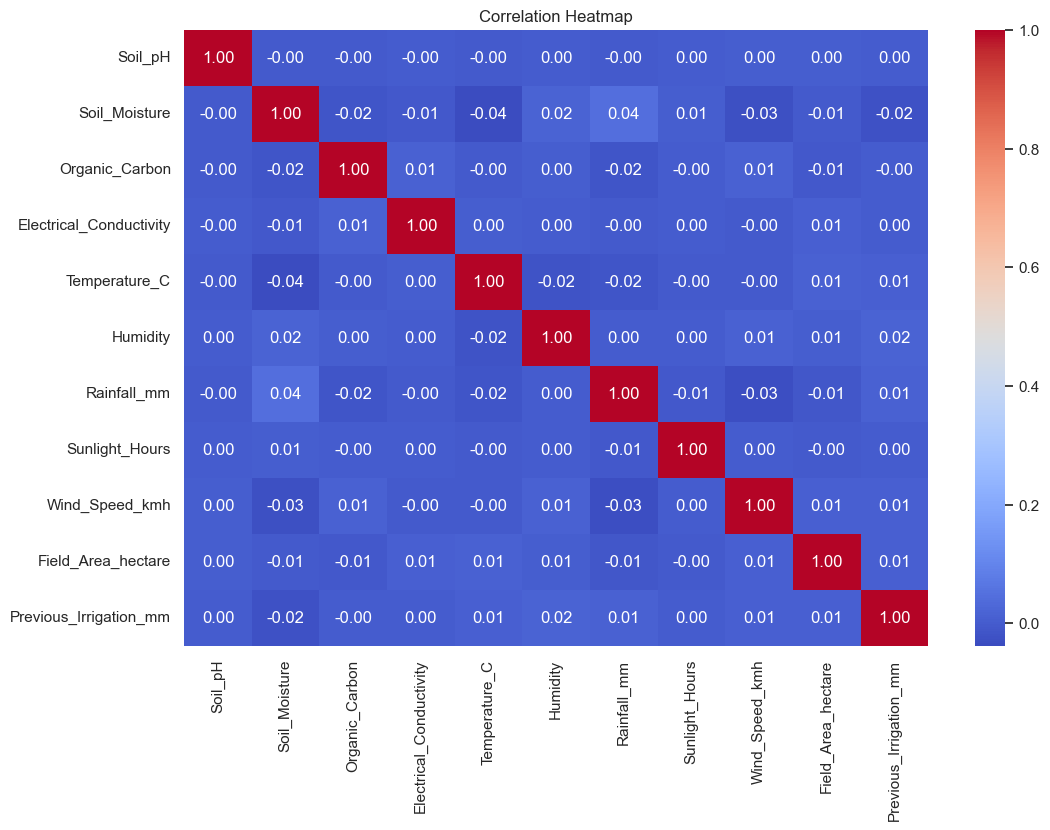

In [12]:
# plot heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [13]:
train.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(train, test_size=0.2, random_state=42, stratify=train['Irrigation_Need'])
print(train_data.shape, val_data.shape)

(504000, 20) (126000, 20)


In [15]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # notebook is in /notebooks, project root is one level up
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.features.build import build_features

y_train = train['Irrigation_Need'].map({'Low': 0, 'Medium': 1, 'High': 2})
y_test = val_data['Irrigation_Need'].map({'Low': 0, 'Medium': 1, 'High': 2})
X_train, X_test = build_features(train, val_data, y_train)



In [16]:
X_train.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Wind_bin,Soil_Type_enc,Crop_Type_enc,Crop_Growth_Stage_enc,Season_enc,Irrigation_Type_enc,Water_Source_enc,Mulching_Used_enc,Region_enc,Crop_Stage_TE
id,,,,,,,,,,,,,,,,,,,,,
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,...,2,1,4,2,2,1,1,0,1,0.122114
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,0,0,5,3,0,2,3,1,3,0.733442
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,...,0,0,3,3,0,3,2,1,2,0.714718
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,...,0,2,5,0,0,0,3,1,3,0.743987
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,...,2,0,5,2,1,0,3,0,3,0.124224


In [17]:
X_test.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Wind_bin,Soil_Type_enc,Crop_Type_enc,Crop_Growth_Stage_enc,Season_enc,Irrigation_Type_enc,Water_Source_enc,Mulching_Used_enc,Region_enc,Crop_Stage_TE
id,,,,,,,,,,,,,,,,,,,,,
511403,5.83,64.41,0.39,1.78,13.22,38.48,1238.91,6.00,15.83,14.46,...,2,0,4,1,1,1,3,1,1,0.147043
498032,6.25,24.48,0.34,2.35,13.96,56.90,1691.41,8.71,13.20,7.08,...,2,1,4,0,1,3,3,0,0,0.782625
200004,6.63,58.40,1.18,0.60,27.32,53.93,2058.21,8.53,19.01,8.66,...,2,3,4,3,2,2,2,0,4,0.744708
383295,6.54,46.11,0.76,3.12,39.37,57.44,1546.99,10.64,3.35,13.85,...,0,2,2,1,0,3,3,1,0,0.163624
303295,7.09,63.10,1.29,0.57,33.77,44.69,1887.80,5.07,11.20,7.45,...,1,0,0,1,0,1,2,0,2,0.157264


In [18]:
import xgboost as xgb

xgb_params = dict(
    objective        = 'multi:softprob',
    num_class        = 3,
    eval_metric      = 'mlogloss',
    tree_method      = 'hist',        # fast on 630k rows; use 'gpu_hist' if you have a GPU
    n_estimators     = 5000,
    early_stopping_rounds = 50,
    learning_rate    = 0.05,
    max_depth        = 7,
    min_child_weight = 5,
    subsample        = 0.80,
    colsample_bytree = 0.80,
    reg_alpha        = 0.1,           # L1 — helps with redundant features
    reg_lambda       = 1.0,           # L2
    random_state     = 42,
    n_jobs           = -1,
)

In [19]:
import numpy as np
from sklearn.utils import compute_class_weight

# Proper balanced weights: 1 / class_frequency for each class
classes = np.array([0, 1, 2])
# weights = compute_class_weight('balanced', classes=classes, y=y_train)
# e.g. → [0.57, 0.88, 10.1] — proportional to 1/freq
# sample_weights = weights[y_train]

In [20]:
# sample_weights

In [21]:

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

'''
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof     = np.zeros((len(X_train), 3))            # out-of-fold probabilities
models  = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    # w_tr        = sample_weights[tr_idx]

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X_tr, y_tr,
        # sample_weight      = w_tr,
        eval_set           = [(X_val, y_val)],
        verbose            = 100,
    )

    oof[val_idx] = model.predict_proba(X_val)
    models.append(model)

    preds  = oof[val_idx].argmax(axis=1)
    bal_acc = balanced_accuracy_score(y_val, preds)
    print(f"Fold {fold+1}  balanced_acc={bal_acc:.4f}")
    '''


'\nskf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\noof     = np.zeros((len(X_train), 3))            # out-of-fold probabilities\nmodels  = []\n\nfor fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):\n    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]\n    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]\n    # w_tr        = sample_weights[tr_idx]\n\n    model = xgb.XGBClassifier(**xgb_params)\n    model.fit(\n        X_tr, y_tr,\n        # sample_weight      = w_tr,\n        eval_set           = [(X_val, y_val)],\n        verbose            = 100,\n    )\n\n    oof[val_idx] = model.predict_proba(X_val)\n    models.append(model)\n\n    preds  = oof[val_idx].argmax(axis=1)\n    bal_acc = balanced_accuracy_score(y_val, preds)\n    print(f"Fold {fold+1}  balanced_acc={bal_acc:.4f}")\n    '

In [22]:
#X_train.to_csv('../data/processed/X_train.csv', index=True)

In [23]:
#y_train.to_csv('../data/processed/y_train.csv', index=True)

In [24]:
'''
model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
'''

'\nmodel_xgb = xgb.XGBClassifier(**xgb_params)\nmodel_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)\n'

In [25]:
X_test_submission = build_features(train, test, y_train)[1]

In [26]:
#predictions = model_xgb.predict(X_test_submission)

In [27]:
'''
predictions = pd.Series(predictions).map({0: 'Low', 1: 'Medium', 2: 'High'})
predictions
'''

"\npredictions = pd.Series(predictions).map({0: 'Low', 1: 'Medium', 2: 'High'})\npredictions\n"

In [28]:
'''
submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': predictions
})
'''

"\nsubmission = pd.DataFrame({\n    'id': test['id'],\n    'Irrigation_Need': predictions\n})\n"

In [29]:
#submission.to_csv('../data/processed/submission.csv', index=False)

In [30]:
# SCORE OF 0.96392 AND 1632 OUT OF 3200

In [31]:
xgb_params_optuna = dict(
    objective        = 'multi:softprob',
    num_class        = 3,
    eval_metric      = 'mlogloss',
    tree_method      = 'hist',        # fast on 630k rows; use 'gpu_hist' if you have a GPU
    n_estimators     = 5000,
    early_stopping_rounds = 50,
    learning_rate    = 0.1318140726170676,
    max_depth        = 9,
    max_leaves       = 18,
    min_child_weight = 15,
    max_delta_step   = 9.826861567778046,
    grow_policy       = 'lossguide',   # best for large datasets; use 'depthwise' for small ones            
    gamma            = 0.2513835672185034,           # minimum loss reduction to make a split
    subsample        = 0.8816746026980318,
    colsample_bytree = 0.8274899707875001,
    colsample_bylevel = 0.9945862330296029,
    colsample_bynode  = 0.9973391381317489,
    reg_alpha        = 1.0522917672315092e-8,           # L1 — helps with redundant features
    reg_lambda       = 2.1172959460625797e-7,           # L2
    random_state     = 42,
    n_jobs           = -1,
)

In [32]:
model_xgb_optuna = xgb.XGBClassifier(**xgb_params_optuna)
model_xgb_optuna.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

[0]	validation_0-mlogloss:0.65050
[100]	validation_0-mlogloss:0.05591
[200]	validation_0-mlogloss:0.05049
[300]	validation_0-mlogloss:0.04695
[400]	validation_0-mlogloss:0.04394
[500]	validation_0-mlogloss:0.04134
[600]	validation_0-mlogloss:0.03899
[700]	validation_0-mlogloss:0.03688
[800]	validation_0-mlogloss:0.03487
[900]	validation_0-mlogloss:0.03306
[1000]	validation_0-mlogloss:0.03137
[1100]	validation_0-mlogloss:0.02979
[1200]	validation_0-mlogloss:0.02834
[1300]	validation_0-mlogloss:0.02694
[1400]	validation_0-mlogloss:0.02560
[1500]	validation_0-mlogloss:0.02437
[1600]	validation_0-mlogloss:0.02321
[1700]	validation_0-mlogloss:0.02215
[1800]	validation_0-mlogloss:0.02114
[1900]	validation_0-mlogloss:0.02023
[2000]	validation_0-mlogloss:0.01937
[2100]	validation_0-mlogloss:0.01856
[2200]	validation_0-mlogloss:0.01780
[2300]	validation_0-mlogloss:0.01713
[2400]	validation_0-mlogloss:0.01650
[2500]	validation_0-mlogloss:0.01592
[2600]	validation_0-mlogloss:0.01540
[2700]	valida

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.9945862330296029
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,0.9973391381317489
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8274899707875001
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from

In [33]:
balanced_accuracy_score(y_test, model_xgb_optuna.predict(X_test))

0.9979917908831634

In [34]:
predictions_optuna = model_xgb_optuna.predict(X_test_submission)

In [35]:
predictions = pd.Series(predictions_optuna).map({0: 'Low', 1: 'Medium', 2: 'High'})

In [36]:
submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': predictions
})

In [37]:
submission.to_csv('../data/processed/submission.csv', index=False)